# ERCOT / DFW Capstone — Clean & Explore (Python)

This is the Python/pandas version of the cleaning + EDA pipeline (originally built in PowerShell — see `../scripts/`). It:

1. Loads the raw Excel file
2. Repairs the timestamp bug (~1 row/day had its time truncated to midnight)
3. Converts text-stored numbers to real numeric columns
4. Adds local time, calendar, and DFW-specific derived columns
5. Saves the clean CSV
6. Re-runs the exploratory analysis from `../reports/02_exploratory_findings.md`

See `../reports/01_data_quality_and_cleaning.md` for the full writeup of the issues fixed here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from zoneinfo import ZoneInfo

pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (10, 4)

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_XLSX = PROJECT_DIR / "data" / "raw" / "ercot_comprehensive_hourly_grid_dataset.xlsx"
CLEAN_CSV = PROJECT_DIR / "data" / "processed" / "ercot_hourly_clean.csv"
print(RAW_XLSX)
print(CLEAN_CSV)

C:\Users\Mateen Jan\Downloads\CLAUDE PROJ\CAPSTONE PROJECT\data\raw\ercot_comprehensive_hourly_grid_dataset.xlsx
C:\Users\Mateen Jan\Downloads\CLAUDE PROJ\CAPSTONE PROJECT\data\processed\ercot_hourly_clean.csv


## 1. Load the raw workbook

In [2]:
raw = pd.read_excel(RAW_XLSX, sheet_name="Hourly Data", header=0)
meta = pd.read_excel(RAW_XLSX, sheet_name="Series Metadata", header=0)

print(raw.shape)
raw.head(3)

(63478, 22)


,timestamp_utc,generation_ng_mwh,generation_col_mwh,generation_nuc_mwh,generation_oth_mwh,generation_sun_mwh,generation_wat_mwh,generation_wnd_mwh,demand_coas_mwh,demand_east_mwh,...,demand_nrth_mwh,demand_scen_mwh,demand_sout_mwh,demand_west_mwh,interchange_cen_mwh,net_generation_mwh,total_interchange_mwh,demand_mwh,interchange_swpp_mwh,day_ahead_demand_forecast_mwh
0,2019-05-27 06:00:00,12805.0,8091.0,3828.0,22.0,0.0,222.0,16159.0,12017.0,1467.0,...,845.0,6294.0,3313.0,1451.0,313.0,41129.0,149.0,40980.0,-164.0,41297.0
1,2019-05-27 07:00:00,11556.0,7245.0,3829.0,25.0,0.0,268.0,15882.0,11416.0,1401.0,...,794.0,5893.0,3114.0,1361.0,192.0,38805.0,-20.0,38825.0,-212.0,39007.0
2,2019-05-27 08:00:00,10709.0,6364.0,3829.0,24.0,0.0,276.0,16194.0,11016.0,1345.0,...,773.0,5621.0,3012.0,1246.0,170.0,37396.0,-7.0,37403.0,-178.0,37325.0


In [3]:
# what each column means, per the workbook's own Series Metadata sheet
meta[["column_name", "name", "units"]]

,column_name,name,units
0,generation_ng_mwh,Net generation from natural gas for Electric R...,megawatthours
1,generation_col_mwh,Net generation from coal for Electric Reliabil...,megawatthours
2,generation_nuc_mwh,Net generation from nuclear for Electric Relia...,megawatthours
3,generation_oth_mwh,Net generation from other for Electric Reliabi...,megawatthours
4,generation_sun_mwh,Net generation from solar for Electric Reliabi...,megawatthours
5,generation_wat_mwh,Net generation from hydro for Electric Reliabi...,megawatthours
6,generation_wnd_mwh,Net generation from wind for Electric Reliabil...,megawatthours
7,demand_coas_mwh,Demand for Electric Reliability Council of Tex...,megawatthours
8,demand_east_mwh,Demand for Electric Reliability Council of Tex...,megawatthours
9,demand_fwes_mwh,Demand for Electric Reliability Council of Tex...,megawatthours


## 2. Fix the timestamp bug

Roughly once per day, a row's timestamp lost its time-of-day and collapsed to bare midnight (`00:00:00`). That both duplicates midnight and leaves a real hour (usually ~05:00 UTC) missing. The row's *values* are genuine — only the *timestamp* is wrong — so we reassign it to the next open hourly slot rather than dropping it. See `reports/01_data_quality_and_cleaning.md` for the full explanation.

In [4]:
ts_col = raw.columns[0]

if not pd.api.types.is_datetime64_any_dtype(raw[ts_col]):
    # openpyxl didn't auto-parse the Excel date serial -> convert it ourselves
    raw[ts_col] = pd.to_datetime(raw[ts_col].astype(float), unit="D", origin="1899-12-30")

raw = raw.rename(columns={ts_col: "timestamp_utc"})
raw["timestamp_utc"] = raw["timestamp_utc"].dt.round("h")

# drop the fully-blank trailing rows the sheet ships with
value_cols = raw.columns[1:]
has_data = raw[value_cols].notna().any(axis=1)
raw = raw[raw["timestamp_utc"].notna() & has_data].reset_index(drop=True)
print(f"{len(raw):,} rows with data")

63,478 rows with data


In [5]:
ts = raw["timestamp_utc"].tolist()
repaired_flag = [False] * len(ts)
n_fixed = 0

for i in range(1, len(ts)):
    prev, cur = ts[i - 1], ts[i]
    if cur <= prev and cur == cur.normalize():  # fell back to a bare date (00:00:00)
        ts[i] = prev + pd.Timedelta(hours=1)
        repaired_flag[i] = True
        n_fixed += 1

raw["timestamp_utc"] = ts
raw["timestamp_repaired"] = repaired_flag
print(f"repaired {n_fixed} timestamps")

repaired 2644 timestamps


In [6]:
raw = raw.sort_values("timestamp_utc").drop_duplicates("timestamp_utc", keep="first")

full_index = pd.date_range(raw["timestamp_utc"].min(), raw["timestamp_utc"].max(), freq="h")
df = raw.set_index("timestamp_utc").reindex(full_index)
df.index.name = "timestamp_utc"
df["timestamp_repaired"] = df["timestamp_repaired"].fillna(False)

gap_hours = df.drop(columns=["timestamp_repaired"]).isna().all(axis=1).sum()
print(f"{len(df):,} hourly rows spanning the full clock, {gap_hours} completely-empty (gap) hours")
assert len(df) > 0

63,478 hourly rows spanning the full clock, 0 completely-empty (gap) hours


## 3. Convert text-stored numbers to real numeric columns

In [7]:
measure_cols = [c for c in df.columns if c != "timestamp_repaired"]
df[measure_cols] = df[measure_cols].apply(pd.to_numeric, errors="coerce")
df[measure_cols].describe().T[["count", "min", "mean", "max"]].round(1)

,count,min,mean,max
generation_ng_mwh,63454.0,411.0,21640.1,51156.0
generation_col_mwh,63454.0,1933.0,7692.2,13907.0
generation_nuc_mwh,63453.0,2442.0,4683.4,5157.0
generation_oth_mwh,63342.0,-8.0,123.2,27137.0
generation_sun_mwh,63450.0,0.0,3970.8,34982.0
generation_wat_mwh,63448.0,0.0,50.5,344.0
generation_wnd_mwh,63454.0,38.0,11839.7,28819.0
demand_coas_mwh,63346.0,4935.0,13396.7,23802.0
demand_east_mwh,63381.0,829.0,1778.8,4800.0
demand_fwes_mwh,63343.0,1087.0,5459.4,9462.0


## 4. Local time, calendar, and DFW-specific derived columns

In [8]:
tz = ZoneInfo("America/Chicago")
df = df.reset_index()
df["timestamp_utc"] = df["timestamp_utc"].dt.tz_localize("UTC")
df["timestamp_local"] = df["timestamp_utc"].dt.tz_convert(tz)

df["year"] = df["timestamp_local"].dt.year
df["month"] = df["timestamp_local"].dt.month
df["hour_local"] = df["timestamp_local"].dt.hour
df["dow_local"] = df["timestamp_local"].dt.dayofweek  # 0 = Monday
df["is_weekend"] = df["dow_local"].isin([5, 6]).astype(int)
df["season"] = df["month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Fall", 10: "Fall", 11: "Fall",
})

In [9]:
df["dfw_demand_mwh"] = df["demand_ncen_mwh"]
df["dfw_share_of_ercot"] = df["demand_ncen_mwh"] / df["demand_mwh"]
df["renewable_gen_mwh"] = df[["generation_wnd_mwh", "generation_sun_mwh", "generation_wat_mwh"]].sum(axis=1, min_count=1)
df["renewable_share"] = df["renewable_gen_mwh"] / df["demand_mwh"]
df["net_load_mwh"] = df["demand_mwh"] - df["generation_wnd_mwh"] - df["generation_sun_mwh"]
df["forecast_error_mwh"] = df["day_ahead_demand_forecast_mwh"] - df["demand_mwh"]
df["abs_pct_error"] = (df["forecast_error_mwh"].abs() / df["demand_mwh"]) * 100
df.head(3)

,timestamp_utc,generation_ng_mwh,generation_col_mwh,generation_nuc_mwh,generation_oth_mwh,generation_sun_mwh,generation_wat_mwh,generation_wnd_mwh,demand_coas_mwh,demand_east_mwh,...,dow_local,is_weekend,season,dfw_demand_mwh,dfw_share_of_ercot,renewable_gen_mwh,renewable_share,net_load_mwh,forecast_error_mwh,abs_pct_error
0,2019-05-27 06:00:00+00:00,12805.0,8091.0,3828.0,22.0,0.0,222.0,16159.0,12017.0,1467.0,...,0,0,Spring,12432.0,0.303367,16381.0,0.399732,24821.0,317.0,0.773548
1,2019-05-27 07:00:00+00:00,11556.0,7245.0,3829.0,25.0,0.0,268.0,15882.0,11416.0,1401.0,...,0,0,Spring,11662.0,0.300373,16150.0,0.415969,22943.0,182.0,0.468770
2,2019-05-27 08:00:00+00:00,10709.0,6364.0,3829.0,24.0,0.0,276.0,16194.0,11016.0,1345.0,...,0,0,Spring,11164.0,0.298479,16470.0,0.440339,21209.0,-78.0,0.208539


## 5. Save the clean dataset

In [10]:
CLEAN_CSV.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(CLEAN_CSV, index=False)
print(f"saved {len(df):,} rows -> {CLEAN_CSV}")

saved 63,478 rows -> C:\Users\Mateen Jan\Downloads\CLAUDE PROJ\CAPSTONE PROJECT\data\processed\ercot_hourly_clean.csv


## 6. Data-quality checks (sanity checks, should both be small)

In [11]:
fuel_cols = ["generation_ng_mwh", "generation_col_mwh", "generation_nuc_mwh", "generation_oth_mwh",
             "generation_sun_mwh", "generation_wat_mwh", "generation_wnd_mwh"]
zone_cols = ["demand_coas_mwh", "demand_east_mwh", "demand_fwes_mwh", "demand_ncen_mwh",
             "demand_nrth_mwh", "demand_scen_mwh", "demand_sout_mwh", "demand_west_mwh"]

# only compare hours where every component is present, so a missing zone/fuel
# doesn't get silently treated as a zero and inflate the "error"
gen_complete = df.dropna(subset=fuel_cols + ["net_generation_mwh"])
zone_complete = df.dropna(subset=zone_cols + ["demand_mwh"])

gen_check = (gen_complete[fuel_cols].sum(axis=1) - gen_complete["net_generation_mwh"]).abs().mean()
zone_check = (zone_complete[zone_cols].sum(axis=1) - zone_complete["demand_mwh"]).abs().mean()
print(f"mean |sum(fuels) - net_generation| = {gen_check:,.1f} MW  (fuels should sum to total, n={len(gen_complete):,})")
print(f"mean |sum(zones) - demand|         = {zone_check:,.1f} MW  (zones should sum to total, n={len(zone_complete):,})")

df[measure_cols].isna().sum().sort_values(ascending=False).head(10)

mean |sum(fuels) - net_generation| = 318.6 MW  (fuels should sum to total, n=63,336)
mean |sum(zones) - demand|         = 148.8 MW  (zones should sum to total, n=63,298)


generation_oth_mwh               136
demand_fwes_mwh                  135
demand_coas_mwh                  132
demand_ncen_mwh                  127
interchange_cen_mwh              106
total_interchange_mwh            106
interchange_swpp_mwh             106
demand_nrth_mwh                  100
demand_east_mwh                   97
day_ahead_demand_forecast_mwh     96
dtype: int64

## 7. DFW (North Central weather zone) demand, by year

In [12]:
by_year = df.groupby("year").agg(
    hours=("demand_ncen_mwh", "size"),
    dfw_avg_mw=("demand_ncen_mwh", "mean"),
    dfw_peak_mw=("demand_ncen_mwh", "max"),
    ercot_avg_mw=("demand_mwh", "mean"),
)
by_year["dfw_share_pct"] = 100 * by_year["dfw_avg_mw"] / by_year["ercot_avg_mw"]
by_year.round(1)

,hours,dfw_avg_mw,dfw_peak_mw,ercot_avg_mw,dfw_share_pct
year,,,,,
2019,5256,14599.1,25307.0,46948.0,31.1
2020,8784,13155.9,25548.0,43375.9,30.3
2021,8760,13388.7,25766.0,44810.1,29.9
2022,8760,14683.4,27569.0,49156.5,29.9
2023,8760,14519.1,28269.0,51006.7,28.5
2024,8784,14785.7,27959.0,52798.1,28.0
2025,8760,15515.6,27927.0,55713.4,27.8
2026,5614,16357.6,29839.0,58385.9,28.0


## 8. DFW diurnal profile by season

In [13]:
diurnal = df.pivot_table(index="hour_local", columns="season", values="demand_ncen_mwh", aggfunc="mean")
diurnal = diurnal[["Winter", "Spring", "Summer", "Fall"]]
diurnal.round(0)

season,Winter,Spring,Summer,Fall
hour_local,,,,
0,12854.0,11832.0,17133.0,12573.0
1,12414.0,11029.0,15877.0,11744.0
2,12190.0,10474.0,14916.0,11200.0
3,12119.0,10121.0,14199.0,10830.0
4,12211.0,9934.0,13717.0,10625.0
5,12536.0,9982.0,13498.0,10663.0
6,13235.0,10377.0,13613.0,11065.0
7,14272.0,11096.0,13893.0,11802.0
8,14925.0,11599.0,14215.0,12236.0


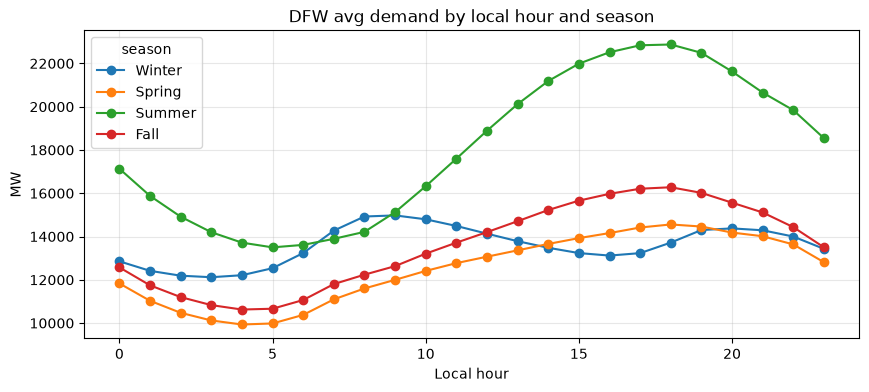

In [14]:
diurnal.plot(marker="o")
plt.title("DFW avg demand by local hour and season")
plt.ylabel("MW"); plt.xlabel("Local hour"); plt.grid(alpha=0.3)
plt.show()

## 9. Day-ahead demand-forecast error (ERCOT system)

In [15]:
err = df.dropna(subset=["day_ahead_demand_forecast_mwh", "demand_mwh"]).copy()
err = err[err["demand_mwh"] != 0]
print(f"Overall MAPE: {err['abs_pct_error'].mean():.2f}%   mean bias: {err['forecast_error_mwh'].mean():.0f} MW")
err.groupby("year")["abs_pct_error"].mean().round(2)

Overall MAPE: 2.44%   mean bias: 259 MW


year
2019    2.22
2020    2.21
2021    2.88
2022    2.79
2023    2.60
2024    2.16
2025    2.46
2026    1.88
Name: abs_pct_error, dtype: float64

## 10. Renewables & net load, by year

In [16]:
ren = df.groupby("year").agg(
    wind_mw=("generation_wnd_mwh", "mean"),
    solar_mw=("generation_sun_mwh", "mean"),
    demand_mw=("demand_mwh", "mean"),
    net_load_mw=("net_load_mwh", "mean"),
)
ren["renew_share_pct"] = 100 * (ren["wind_mw"] + ren["solar_mw"]) / ren["demand_mw"]
ren.round(0)

,wind_mw,solar_mw,demand_mw,net_load_mw,renew_share_pct
year,,,,,
2019,8538.0,506.0,46948.0,37903.0,19.0
2020,9916.0,944.0,43376.0,32515.0,25.0
2021,10899.0,1740.0,44810.0,32172.0,28.0
2022,12257.0,2702.0,49156.0,34198.0,30.0
2023,12328.0,3638.0,51007.0,35041.0,31.0
2024,12718.0,5438.0,52798.0,34642.0,34.0
2025,13141.0,7724.0,55713.0,34855.0,37.0
2026,14594.0,9795.0,58386.0,33996.0,42.0


## 11. Correlation of DFW demand with other series

In [17]:
corr_cols = ["demand_ncen_mwh", "demand_mwh", "demand_coas_mwh", "demand_scen_mwh", "demand_fwes_mwh",
             "generation_ng_mwh", "generation_wnd_mwh", "generation_sun_mwh", "total_interchange_mwh"]
df[corr_cols].corr()["demand_ncen_mwh"].sort_values(ascending=False).round(3)

demand_ncen_mwh          1.000
demand_mwh               0.949
demand_scen_mwh          0.930
demand_coas_mwh          0.853
generation_ng_mwh        0.762
generation_sun_mwh       0.395
demand_fwes_mwh          0.267
generation_wnd_mwh      -0.083
total_interchange_mwh   -0.175
Name: demand_ncen_mwh, dtype: float64

## 12. Spotlight: Winter Storm Uri (Feb 13–19, 2021)

In [18]:
uri = df[(df["timestamp_local"] >= "2021-02-13") & (df["timestamp_local"] < "2021-02-20")].copy()
uri["date_local"] = uri["timestamp_local"].dt.date
uri_daily = uri.groupby("date_local").agg(
    dfw_avg=("demand_ncen_mwh", "mean"), dfw_min=("demand_ncen_mwh", "min"), dfw_max=("demand_ncen_mwh", "max"),
    ercot_avg=("demand_mwh", "mean"), wind_avg=("generation_wnd_mwh", "mean"), gas_avg=("generation_ng_mwh", "mean"),
)
uri_daily.round(0)

,dfw_avg,dfw_min,dfw_max,ercot_avg,wind_avg,gas_avg
date_local,,,,,,
2021-02-13,20339.0,18418.0,22941.0,58720.0,4034.0,37191.0
2021-02-14,22551.0,18871.0,25766.0,62018.0,7237.0,37092.0
2021-02-15,18815.0,16724.0,24086.0,50152.0,3223.0,32202.0
2021-02-16,18125.0,16888.0,19001.0,45055.0,3695.0,28919.0
2021-02-17,18791.0,17792.0,20050.0,45160.0,2546.0,29810.0
2021-02-18,19001.0,17923.0,20335.0,51696.0,5812.0,31597.0
2021-02-19,18100.0,14553.0,21697.0,49153.0,6007.0,27003.0


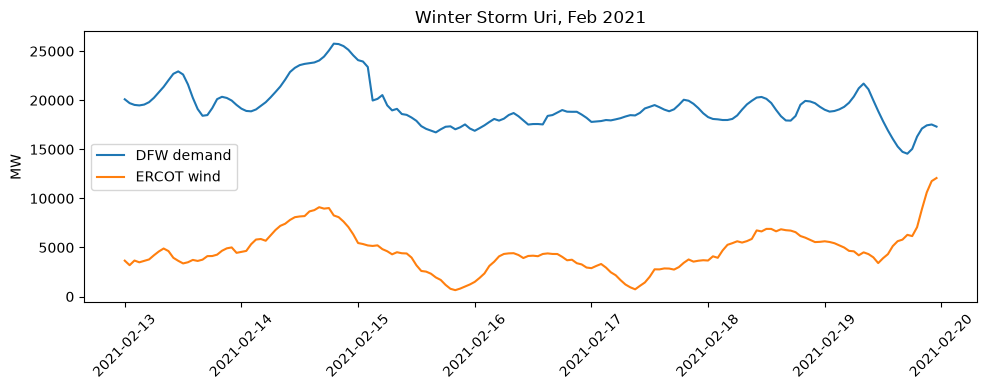

In [19]:
plt.plot(uri["timestamp_local"], uri["demand_ncen_mwh"], label="DFW demand")
plt.plot(uri["timestamp_local"], uri["generation_wnd_mwh"], label="ERCOT wind")
plt.legend(); plt.title("Winter Storm Uri, Feb 2021"); plt.ylabel("MW")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()